In [ ]:
# Random Forests

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load and prepare cleaned Titanic data
# Same split as the Decision Tree notebook for fair comparison.

DATA_PATH = "titanic_cleaned.csv"


def load_data():
    data = pd.read_csv(DATA_PATH)
    y = data["survived"]
    X = data.drop(columns=["survived", "alive"])
    X = pd.get_dummies(X, drop_first=False, dtype=int)
    target_names = np.array(["Did not survive", "Survived"])
    return X, y, target_names


X, y, target_names = load_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset shape:", X.shape)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
X.head()

Dataset shape: (673, 21)
Training shape: (538, 21)
Test shape: (135, 21)


,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,embarked_C,...,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,3,22.0,1,0,7.2500,True,False,0,1,0,...,1,0,0,1,0,1,0,0,0,1
1,1,38.0,1,0,71.2833,False,False,1,0,1,...,0,1,0,0,0,0,1,1,0,0
2,3,26.0,0,0,7.9250,False,True,1,0,0,...,1,0,0,1,0,0,1,0,0,1
3,1,35.0,1,0,53.1000,False,False,1,0,0,...,1,1,0,0,0,0,1,0,0,1
4,3,35.0,0,0,8.0500,True,True,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [4]:
# Single Tree Baseline (from Day 1, for comparison)

single_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
single_tree.fit(X_train, y_train)
tree_acc = accuracy_score(y_test, single_tree.predict(X_test))
print("Single Tree Accuracy:", tree_acc)

Single Tree Accuracy: 0.7185185185185186


In [5]:
# Random Forest Baseline

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
rf_pred = rf_baseline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)
print("Number of trees:", rf_baseline.n_estimators)

Random Forest Accuracy: 0.6888888888888889
Number of trees: 100


In [7]:
# Single Tree vs Forest — Direct Comparison

comparison = pd.DataFrame({
    "Model": ["Single Decision Tree", "Random Forest"],
    "Accuracy": [tree_acc, rf_acc]
})
comparison

,Model,Accuracy
0,Single Decision Tree,0.718519
1,Random Forest,0.688889


age                        0.255177
fare                       0.253766
who_man                    0.064901
sex_male                   0.054583
adult_male                 0.054522
sex_female                 0.043629
sibsp                      0.043235
pclass                     0.042599
class_Third                0.041379
parch                      0.025469
who_woman                  0.023125
class_Second               0.022062
alone                      0.014576
who_child                  0.010866
class_First                0.009819
embark_town_Cherbourg      0.009524
embark_town_Southampton    0.009055
embarked_C                 0.008142
embarked_S                 0.007565
embark_town_Queenstown     0.003007
embarked_Q                 0.002998
dtype: float64


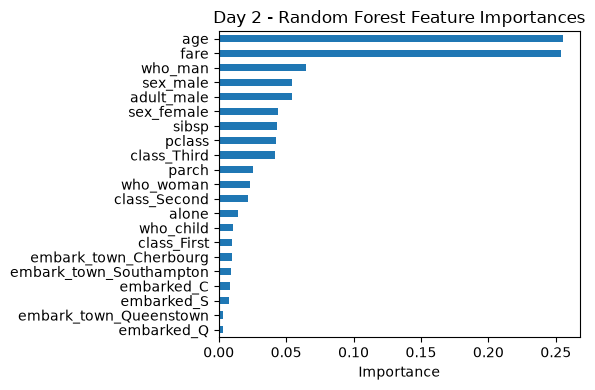

In [6]:
# Feature Importance

importances = pd.Series(rf_baseline.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(6, 4))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Day 2 - Random Forest Feature Importances")
plt.tight_layout()
plt.show()


In [8]:
# Hyperparameter Tuning

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_rf = grid.best_estimator_
best_pred = best_rf.predict(X_test)
print("Tuned RF Test Accuracy:", accuracy_score(y_test, best_pred))
print(classification_report(y_test, best_pred, target_names=target_names))

Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV Accuracy: 0.8160263066805123
Tuned RF Test Accuracy: 0.7333333333333333
                 precision    recall  f1-score   support

Did not survive       0.73      0.93      0.82        86
       Survived       0.76      0.39      0.51        49

       accuracy                           0.73       135
      macro avg       0.74      0.66      0.66       135
   weighted avg       0.74      0.73      0.71       135



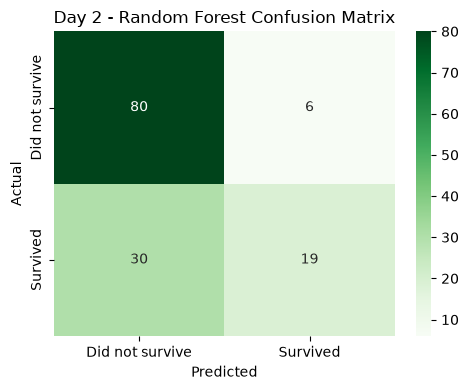

In [9]:
# Confusion Matrix (Tuned Forest)

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Day 2 - Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

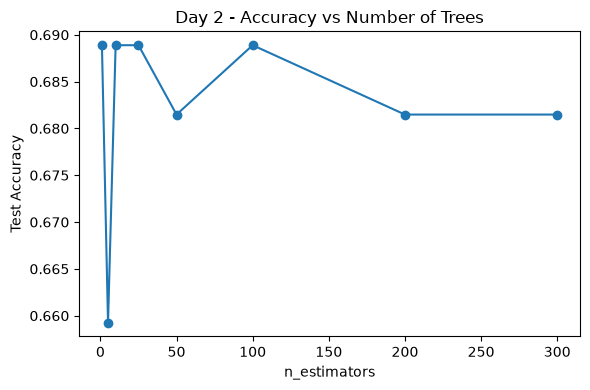

In [10]:
#  n_estimators vs Accuracy

tree_counts = [1, 5, 10, 25, 50, 100, 200, 300]
accs = []
for n in tree_counts:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    accs.append(clf.score(X_test, y_test))

plt.figure(figsize=(6, 4))
plt.plot(tree_counts, accs, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Test Accuracy")
plt.title("Day 2 - Accuracy vs Number of Trees")
plt.tight_layout()
plt.show()